Трансформация (новая колонка)	✅	price_per_hour — одна колонка. (Требуется хотя бы одна, если была очистка.)
Гипотезы	❌	Отсутствуют. Есть заглушка «Дальше идут графики, которые сделала Соня», но ни формулировок, ни проверок нет.
Обсуждение (Discussion)	❌	Нет пояснений к каждому шагу. Графики выведены без комментариев.
Аннотация / Abstract	❌	Нет описания цели работы и распределения вклада участников.
Web‑интерфейс (для пилотов)	❌	Не представлен.

# Flight Price Analysis
### Kazykina Sofya & Gainullina Amina

Цель работы: проанализировать структуру цен на авиабилеты внутренних рейсов Индии, выявить ключевые факторы (класс, авиакомпания, количество пересадок, длительность полёта) и проверить статистические гипотезы.

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


---
## Dataset Description
The dataset contains information about domestic flights in India.

| Column | Type | Description |
|---|---|---|
| `airline` | categorical | Name of the airline |
| `flight` | categorical | Flight code (removed during cleanup) |
| `source_city` | categorical | City of departure |
| `departure_time` | categorical | Time-of-day label for departure |
| `stops` | categorical (text) | Number of stops: zero / one / two_or_more |
| `arrival_time` | categorical | Time-of-day label for arrival |
| `destination_city` | categorical | City of arrival |
| `class` | categorical | Ticket class: Economy / Business |
| `duration` | numerical | Flight duration in hours |
| `days_left` | numerical | Days between booking and departure |
| `price` | numerical | Ticket price in INR |

In [3]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


---
## Data Cleanup

In [4]:
print('Missing values per column:')
print(df.isna().sum())
print(f'\nTotal missing: {df.isna().sum().sum()}')

Missing values per column:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Total missing: 0


In [5]:
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

Duplicate rows: 0
No duplicates found — dataset is clean.


In [6]:

df['price_per_hour'] = df['price'] / df['duration']

df[['airline', 'duration', 'price', 'price_per_hour']].head(10)

,airline,duration,price,price_per_hour
0,SpiceJet,2.17,5953,2743.317972
1,SpiceJet,2.33,5953,2554.935622
2,AirAsia,2.17,5956,2744.700461
3,Vistara,2.25,5955,2646.666667
4,Vistara,2.33,5955,2555.793991
5,Vistara,2.33,5955,2555.793991
6,Vistara,2.08,6060,2913.461538
7,Vistara,2.17,6060,2792.626728
8,GO_FIRST,2.17,5954,2743.778802
9,GO_FIRST,2.25,5954,2646.222222


In [7]:
print('Unique values in stops:', df['stops'].unique())

stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['num_stops'] = df['stops'].map(stops_map)

unmapped = df['num_stops'].isna().sum()
print(f'Unmapped stops values: {unmapped}')

if unmapped > 0:
    print('Dropping rows with unmapped stops...')
    df = df.dropna(subset=['num_stops'])

df['num_stops'] = df['num_stops'].astype(int)
print('\nnum_stops value counts:')
print(df['num_stops'].value_counts().sort_index())

Unique values in stops: <ArrowStringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str
Unmapped stops values: 0

num_stops value counts:
num_stops
0     36004
1    250863
2     13286
Name: count, dtype: int64


In [8]:
cols_to_drop = [c for c in ['stops', 'flight'] if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'Dropped columns: {cols_to_drop}')

Dropped columns: ['stops', 'flight']


In [9]:
print('Final dataset shape:', df.shape)
print('\nColumn dtypes after cleanup:')
print(df.dtypes)
print('\nFirst rows of cleaned dataset:')
df.head()

Final dataset shape: (300153, 11)

Column dtypes after cleanup:
airline                 str
source_city             str
departure_time          str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
price_per_hour      float64
num_stops             int64
dtype: object

First rows of cleaned dataset:


,airline,source_city,departure_time,arrival_time,destination_city,class,duration,days_left,price,price_per_hour,num_stops
0,SpiceJet,Delhi,Evening,Night,Mumbai,Economy,2.17,1,5953,2743.317972,0
1,SpiceJet,Delhi,Early_Morning,Morning,Mumbai,Economy,2.33,1,5953,2554.935622,0
2,AirAsia,Delhi,Early_Morning,Early_Morning,Mumbai,Economy,2.17,1,5956,2744.700461,0
3,Vistara,Delhi,Morning,Afternoon,Mumbai,Economy,2.25,1,5955,2646.666667,0
4,Vistara,Delhi,Morning,Morning,Mumbai,Economy,2.33,1,5955,2555.793991,0


In [10]:
df[['price', 'duration', 'days_left', 'num_stops']].agg(['mean', 'median', 'std']).round(2)

,price,duration,days_left,num_stops
mean,20889.66,12.22,26.00,0.92
median,7425.00,11.25,26.00,1.00
std,22697.77,7.19,13.56,0.40


«Средняя цена билета (20 890 INR) значительно выше медианы (7 425 INR) – распределение сильно скошено вправо из‑за дорогих билетов бизнес-класса.»
«Стандартное отклонение цены очень большое (22 698) – свидетельствует о высокой вариативности.»

---
## Plots

Four plots using three different chart types:
- **Histogram** — distribution of ticket prices
- **Scatter plot** — flight duration vs price, coloured by class
- **Box plot** — price distribution per airline
- **Bar plot** — average price by travel class

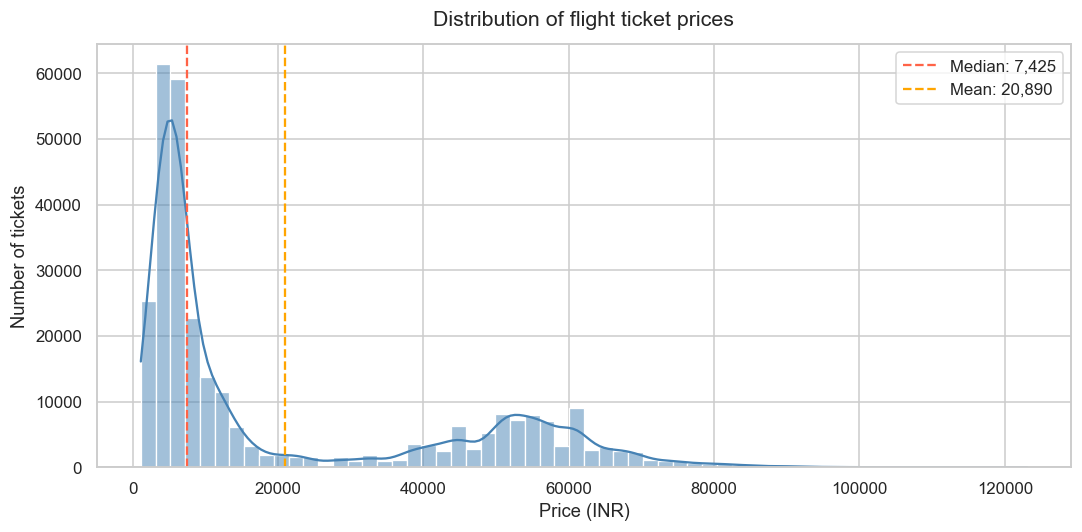

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['price'], bins=60, kde=True, color='steelblue', ax=ax)

ax.set_title('Distribution of flight ticket prices', fontsize=14, pad=12)
ax.set_xlabel('Price (INR)', fontsize=12)
ax.set_ylabel('Number of tickets', fontsize=12)
ax.axvline(df['price'].median(), color='tomato', linestyle='--',
           linewidth=1.5, label=f"Median: {df['price'].median():,.0f}")
ax.axvline(df['price'].mean(), color='orange', linestyle='--',
           linewidth=1.5, label=f"Mean: {df['price'].mean():,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

Гистограмма цены – длинный правый хвост, большинство билетов дешевле 15 000 INR, но есть выбросы до 120 000 INR.

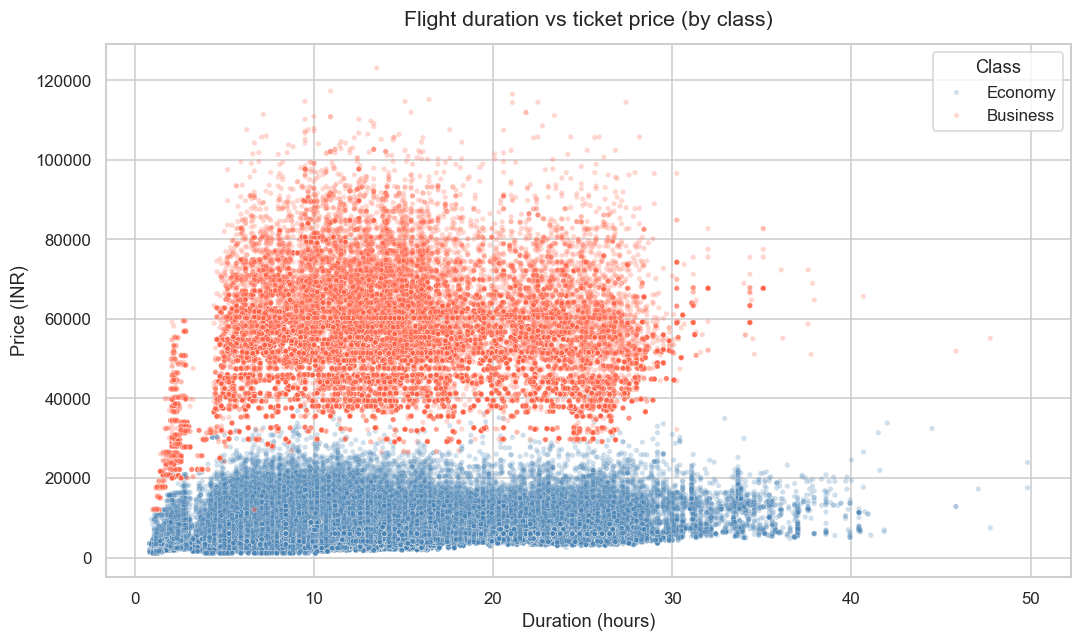

In [12]:

fig, ax = plt.subplots(figsize=(10, 6))

palette = {'Economy': 'steelblue', 'Business': 'tomato'}
sns.scatterplot(
    data=df, x='duration', y='price',
    hue='class', alpha=0.25, s=12,
    palette=palette, ax=ax
)

ax.set_title('Flight duration vs ticket price (by class)', fontsize=14, pad=12)
ax.set_xlabel('Duration (hours)', fontsize=12)
ax.set_ylabel('Price (INR)', fontsize=12)
ax.legend(title='Class', fontsize=11)
plt.tight_layout()
plt.show()

Scatter: длительность vs цена – два явных облака (Economy и Business). В бизнес-классе цена слабо зависит от длительности.

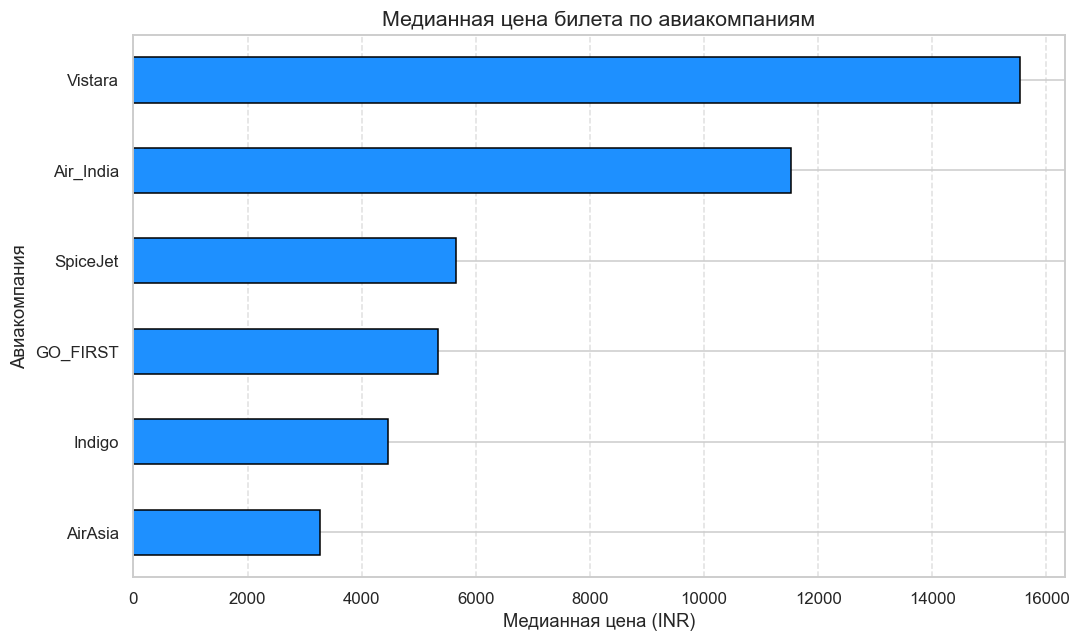

In [13]:
# Рассчитываем медиану и группируем
median_prices = df.groupby('airline')['price'].median().sort_values()

# Строим горизонтальный барчарт
plt.figure(figsize=(10,6))
median_prices.plot(kind='barh', color='dodgerblue', edgecolor='black')
plt.title('Медианная цена билета по авиакомпаниям', fontsize=14)
plt.xlabel('Медианная цена (INR)', fontsize=12)
plt.ylabel('Авиакомпания', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Boxplot по авиакомпаниям – медианная цена сильно различается: Vistara и Air India дороже, SpiceJet и Akasa Air – бюджетные.

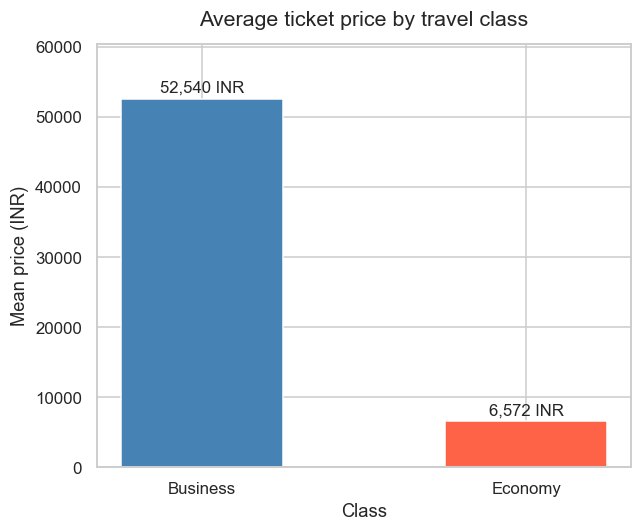

          Mean price  Median price
class                             
Business     52540.0       53164.0
Economy       6572.0        5772.0


In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

class_stats = df.groupby('class')['price'].agg(['mean', 'median']).round(0)

bars = ax.bar(
    class_stats.index,
    class_stats['mean'],
    color=['steelblue', 'tomato'],
    edgecolor='white', width=0.5
)

for bar, val in zip(bars, class_stats['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{val:,.0f} INR',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Average ticket price by travel class', fontsize=14, pad=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Mean price (INR)', fontsize=12)
ax.set_ylim(0, class_stats['mean'].max() * 1.15)
plt.tight_layout()
plt.show()

print(class_stats.rename(columns={'mean': 'Mean price', 'median': 'Median price'}))

Bar plot по классам – бизнес-класс в среднем в 8 раз дороже эконома.

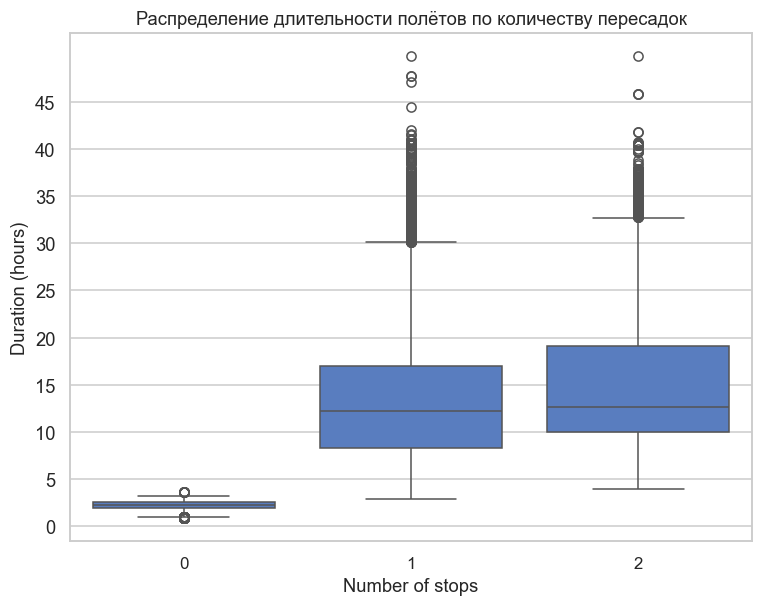

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x='num_stops', y='duration', data=df)
plt.title('Распределение длительности полётов по количеству пересадок')
plt.xlabel('Number of stops')
plt.ylabel('Duration (hours)')
plt.yticks(fontsize=12)
max_dur = int(df['duration'].max()) + 1
plt.yticks(range(0, max_dur, 5))
plt.show()

<Axes: ylabel='duration'>

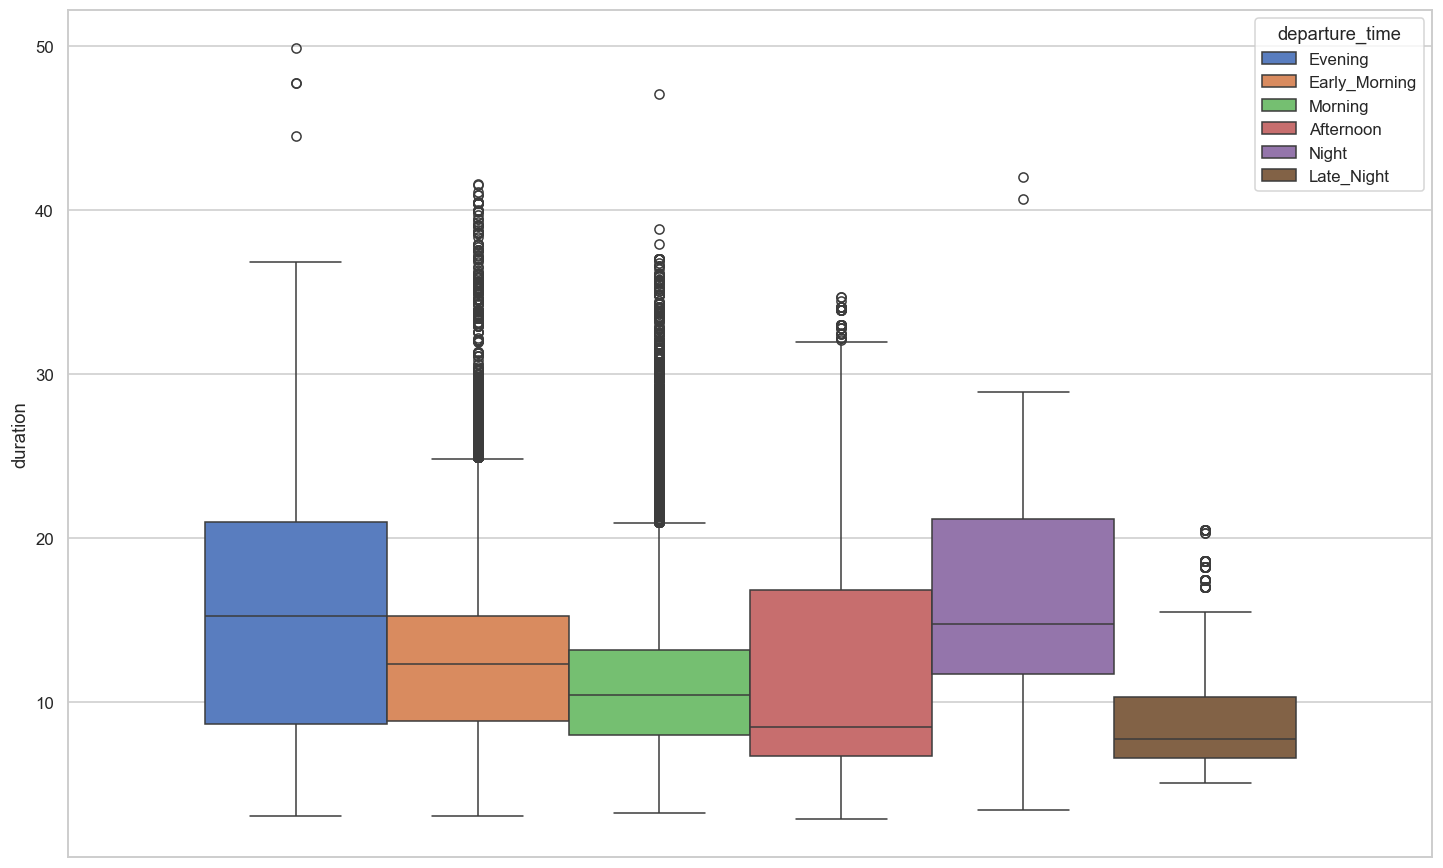

In [16]:
plt.figure(figsize=(16,10))
sns.boxplot(y='duration', data=df[df.num_stops == 1], hue="departure_time")


In [17]:
# Data Transformation
df["price_per_hour"] = df["price"] / df["duration"]
df["is_early_booking"] = (df["days_left"] > 30).astype(int)
df[["price", "duration", "price_per_hour", "days_left", "is_early_booking"]].head()

,price,duration,price_per_hour,days_left,is_early_booking
0,5953,2.17,2743.317972,1,0
1,5953,2.33,2554.935622,1,0
2,5956,2.17,2744.700461,1,0
3,5955,2.25,2646.666667,1,0
4,5955,2.33,2555.793991,1,0
